In [1]:
import os
from pathlib import Path

def root_dir(marker="EXPLib"):
    cwd = Path.cwd()
    # if cwd already contains the marker
    if (cwd / marker).is_dir():
        return cwd
    # otherwise walk up the parents
    for p in cwd.parents:
        if (p / marker).is_dir():
            return p
    raise FileNotFoundError(f"Root marker '{marker}' not found")

os.chdir(root_dir())
#print(os.getcwd())

In [3]:
import torch
from EXPLib.xai_library.model_explainers.model_utils.toymodel_utils import load_and_configure_model
from EXPLib.xai_library.model_explainers.distances_metrics.mmd_utils import register_hooks, load_images_from_folder, collect_features, compute_layer_mmd, estimate_sigma_median_heuristic, collect_flattened_images, compute_mmd, plot_mmd

In [4]:
weight_path = 'EXPLib/dl_component/CNN/Object_Detectors/toy_model_v1'
weight_file = 'aikonet_toymodelv1_ssdlite.pth'

model_name = 'ssdlite320_mobilenet_v3_large'
num_classes = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
model = load_and_configure_model(model_name, weight_path, weight_file, num_classes, device)
res = model.eval()

In [6]:
dataset1_path = 'EXPLib/datasets/Camera/toy_model_v1_inference/dev/images'
dataset2_path = 'EXPLib/datasets/Camera/250127-toymodel_dataset_ufo/data_test_ufo'
sigma = 1.0 
limit = 50
resize_height = 320
resize_width = 320
hook_layer_types = torch.nn.Conv2d

Loading images from EXPLib/datasets/Camera/toy_model_v1_inference/dev/images: 100%|██████████| 50/50 [00:00<00:00, 359.34it/s]
Loading images from EXPLib/datasets/Camera/250127-toymodel_dataset_ufo/data_test_ufo: 100%|██████████| 20/20 [00:00<00:00, 449.47it/s]


Computing layer-wise MMD...
Computing raw image MMD...
MMD Distance between datasets (raw images): 0.0700


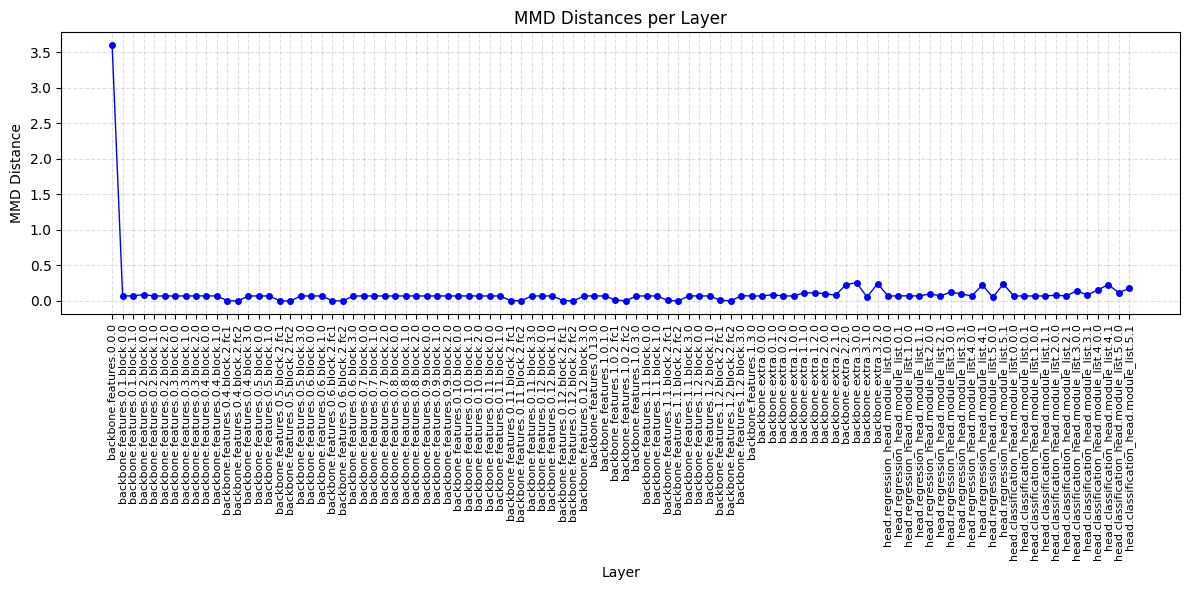

In [7]:
activations = register_hooks(model, layer_types=hook_layer_types)

images1 = load_images_from_folder(dataset1_path, device,
                                      resize_height=resize_height, resize_width=resize_width,
                                      limit=limit)
images2 = load_images_from_folder(dataset2_path, device,
                                      resize_height=resize_height, resize_width=resize_width,
                                      limit=limit)

pretrained_features = collect_features(model, images1, activations)
new_features = collect_features(model, images2, activations)

print("Computing layer-wise MMD...")
layer_mmd_distances = compute_layer_mmd(pretrained_features, new_features, sigma=sigma)

print("Computing raw image MMD...")
pretrained_images = collect_flattened_images(images1)
new_images = collect_flattened_images(images2)

if sigma is None:
    sigma_images = estimate_sigma_median_heuristic(pretrained_images, new_images)
else:
    sigma_images = float(sigma)

dataset_mmd_distance = compute_mmd(pretrained_images, new_images, sigma=sigma_images)

print(f"MMD Distance between datasets (raw images): {dataset_mmd_distance.item():.4f}")

plot_mmd(layer_mmd_distances, title="MMD Distances per Layer")